In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Parsers as P, Optics as O
from mppi.Utilities import Constants as C, Utils as U
from mppi.Utilities import FourierTransform as FT
import matplotlib.pyplot as plt
import numpy as np
import os

# Analysis of the Optics modules

This notebook describes the various modules of the package built in order to extract both the linear and non-linear optical properties of a system
from the knowledge of the real-time polarization.

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime using a delta-shaped pulse

In [3]:
file = 'Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear'

In [4]:
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [5]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

The module can deal with both time variables expressed in fs or in au.

The damp_ft function applies a damping in the time domain to produce a spread in the frequency domain and avoid 
spurious oscillations of the optical quantities.
The damping eta is expressed in eV

In [6]:
P_damped = U.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')

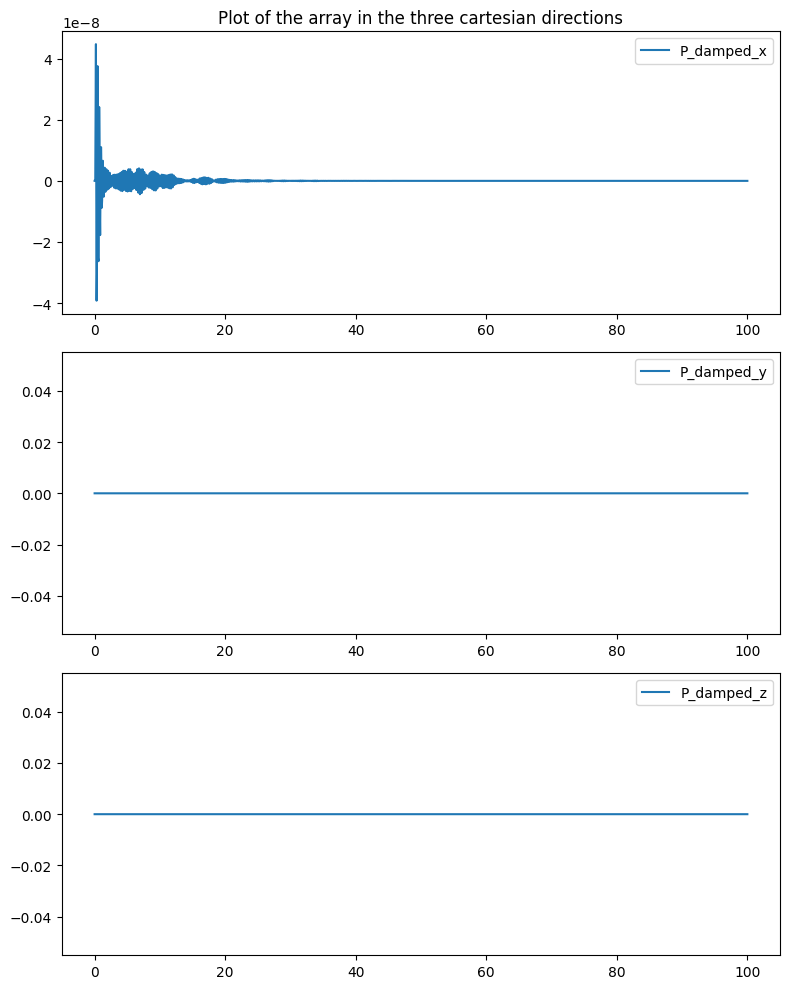

In [7]:
U.Plot_3dArray(time_fs,P_damped,label='P_damped')

The linear response is computed by the Linear_response function of the module

In [8]:
energy,chi = O.Linear_Response(time_fs,P_t,efield=efield,eta=0.1,time_units='fs')

Time units = fs. Rescaled to au


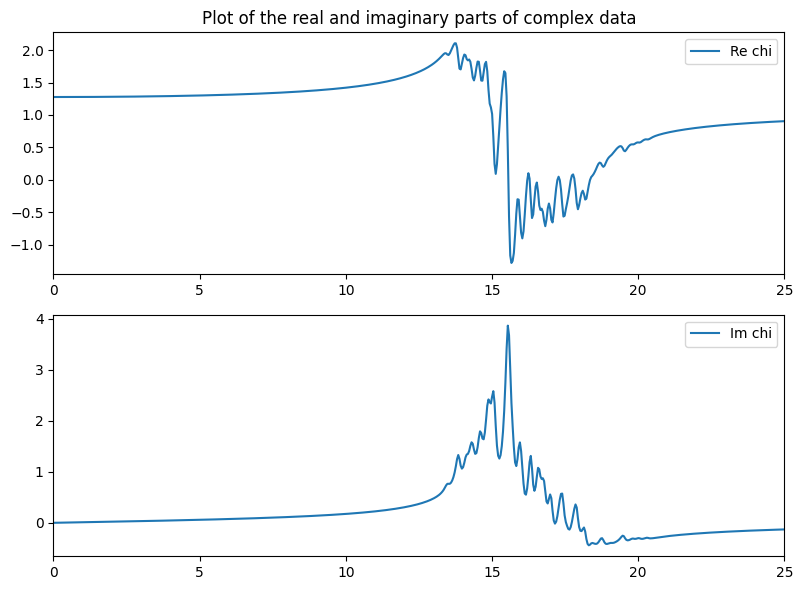

In [9]:
U.Plot_ComplexArray(energy,chi,xlim=(0,25),label='chi')

## Non-linear analysis for a sine-shaped pulse

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [3]:
file = 'Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [4]:
nl = O.Xn_single_frequency(data,Trange=[-1,-1],X_order=3,inactive_harmonics=None)

Time range of the simulation (in au): 0.0 - 8268.274667312273
Time range of the simulation (in fs): 0.0 - 200.00000162820604
Type of the external field: SIN
Order of the non-linear susceptibility extracted: 3
Number of frequencies: 50
Frequency range of the field (in Hartree): 0.18374663009599138 - 0.9040334200722775
Frequency range of the field (in eV): 5.000000477741239 - 24.600002350486893
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs


In [225]:
results_xyz = nl.perform_harmonic_analysis(0)

In [226]:
results_xyz[0][1]

np.float64(7.003216227650225e-13)

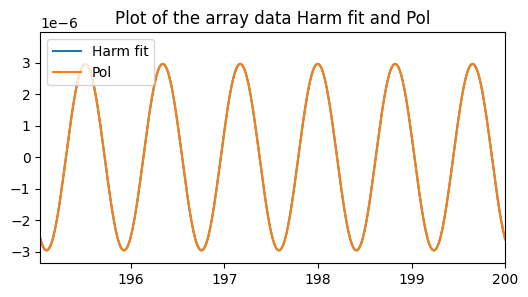

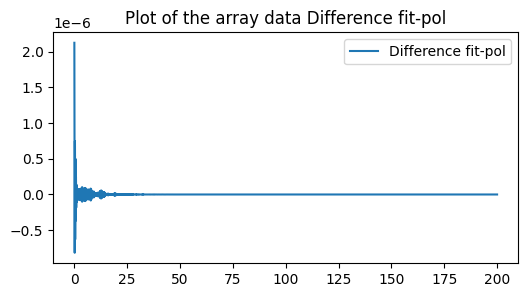

In [227]:
nl.check_harmonic_reliability(plot_ifreq=0)

In [5]:
freqs_sine = nl.fields_freqs*C.HaToeV
chi_sine = nl.compute_Xn(plot=False,set_units_of_measure=True)

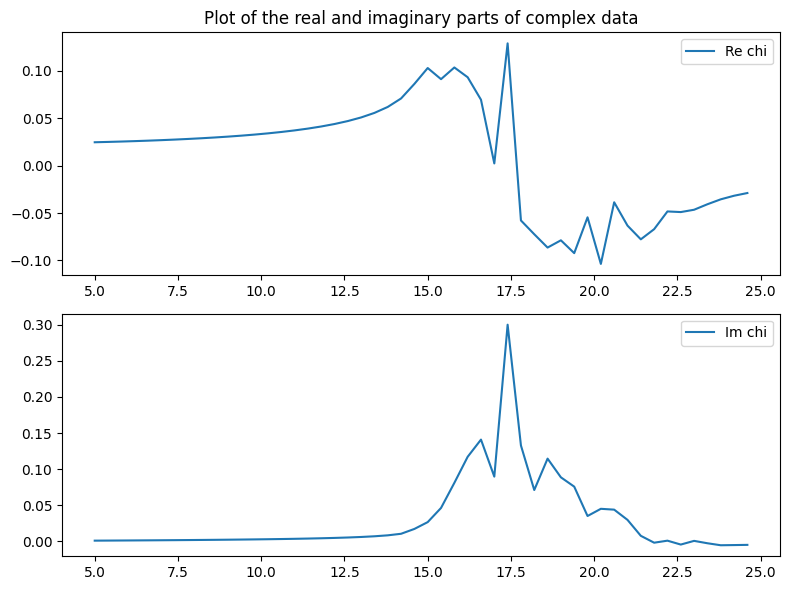

In [6]:
U.Plot_ComplexArray(freqs_sine,chi_sine[0][1],label='chi')

We compare this result with the one of the YamboPy module

In [7]:
from mppi.Optics import NLanalysisYamboPy as NLYP

In [8]:
SIG = NLYP.Xn_from_sine(data,X_order=3,solver='lstsq',nsamp=-1,debug_mode=False) #,T_range=[10*C.FsToAu,200*C.FsToAu]
#,T_range=[50.0*C.FsToAu,100.0*C.FsToAu]
print(SIG)

out = SIG.perform_analysis()
freqs,chi_sine_yp = SIG.output_analysis(out)


 * * *  Xn from signal class  * * * 

Max time: 8268.274667312273
Time step : 0.4134137333656136
Type Efield    : SIN
Number of runs   : 50
Max harmonic order   : 3
Solver           : lstsq
Frequency range: [0.18374663009599138,0.9040334200722775] [au] 



100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 1634.91it/s]

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic o

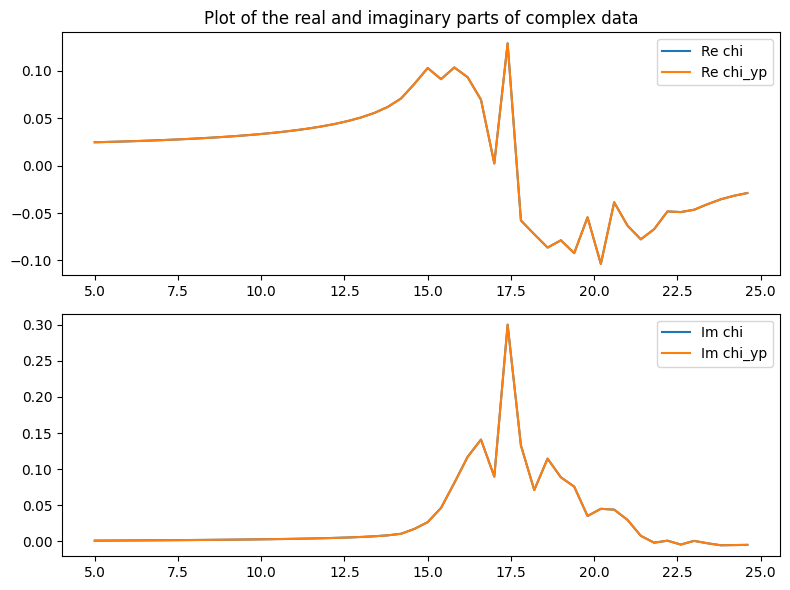

In [9]:
harm = 1
U.Plot_ComplexArray(freqs_sine,chi_sine[0][harm],label='chi',data2=chi_sine_yp[harm,:,0],label2='chi_yp')

## Non-linear analysis for frequency mixing

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [10]:
file = 'Reference_data/nl_results/LiF-pump_1.55-nlenrange_5.0-25.0-nlensteps_80-bands_3-6-damp_0.2-sin/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-pump_1.55-nlenrange_5.0-25.0-nlensteps_80-bands_3-6-damp_0.2-sin/ndb.Nonlinear
Field 3 not found


In [11]:
nl = O.Xn_frequency_mixing(data,Trange=[-1,-1],X_order=(2,2),verbose=False)
nl.get_info()

Time range of the simulation (in au): 0.0 - 6201.206000484204
Time range of the simulation (in fs): 0.0 - 150.00000122115452
Type of the probe field: SIN
Type of the pump field: SIN
Order of the non-linear susceptibility extracted: (2, 2) (probe,pump)
Number of frequencies: 80
Frequency range of the probe (in Hartree): 0.18374663009599138 - 0.9095458189751573
Frequency range of the probe (in eV): 5.000000477741239 - 24.75000236481913
Frequency of the pump : 0.05696145532975733  Hartree - 1.550000148099784  eV
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 1632.6830039999998 au 39.492713606778366 fs


3949
Tmin,Tmax for the plot: 3949 39.49000032148928 52.83086257282052


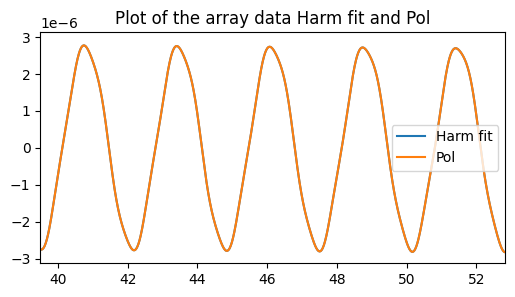

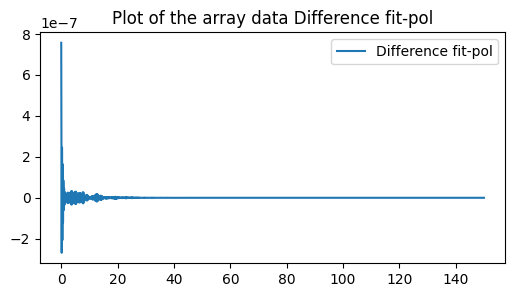

In [12]:
nl.check_harmonic_reliability(plot_ifreq=5)

In [13]:
freqs_freqmix = nl.probe_freqs*C.HaToeV
chi_freqmix = nl.compute_Xn(plot=False,set_units_of_measure=True)

We compare the terms that depends on the probe only with the ones obtained with the single pulse approach

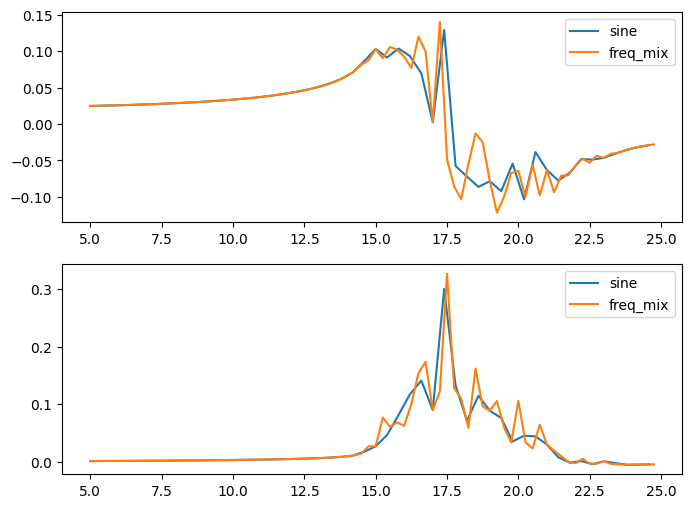

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))
axes[0].plot(freqs_sine,np.real(chi_sine[0][1]),label='sine')
axes[0].plot(freqs_freqmix,np.real(chi_freqmix[0][(1,0)]),label='freq_mix')
axes[1].plot(freqs_sine,np.imag(chi_sine[0][1]),label='sine')
axes[1].plot(freqs_freqmix,np.imag(chi_freqmix[0][(1,0)]),label='freq_mix')
axes[0].legend()
axes[1].legend()

also the quadratic term matches.

Now we compare these results with the ones of YamboPy

In [23]:
from mppi.Optics import NLanalysisYamboPy as NLYP

In [24]:
SIG = NLYP.Xn_from_freqmix(data,X_order=2,solver='lstsq',nsamp=-1,debug_mode=False)
print(SIG)


 * * *  Xn from signal class  * * * 

Max time: 6201.206000484204
Time step : 0.4134137333656136
Type Efield    : SIN
Number of runs   : 80
Max harmonic order   : 2
Solver           : lstsq
Frequency range: [0.18374663009599138,0.9095458189751573] [au] 



In [25]:
out = SIG.perform_analysis()
_,chi_freqmix_yp = SIG.output_analysis(out)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:17<00:00,  4.59it/s]

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-10
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : [2, 2]
# Solver               : lstsq
# Sampling points      : 625
# Start sampling time  : 78.98542721355673 [fs] 



In [26]:
chi_freqmix_yp.shape

(25, 80, 3)

The first index runs over the double loop of all the order of the probe and pumps.

In this case the (1,0) corresponds to 17, (1,1) to 18, (1,2) to 19 and so on

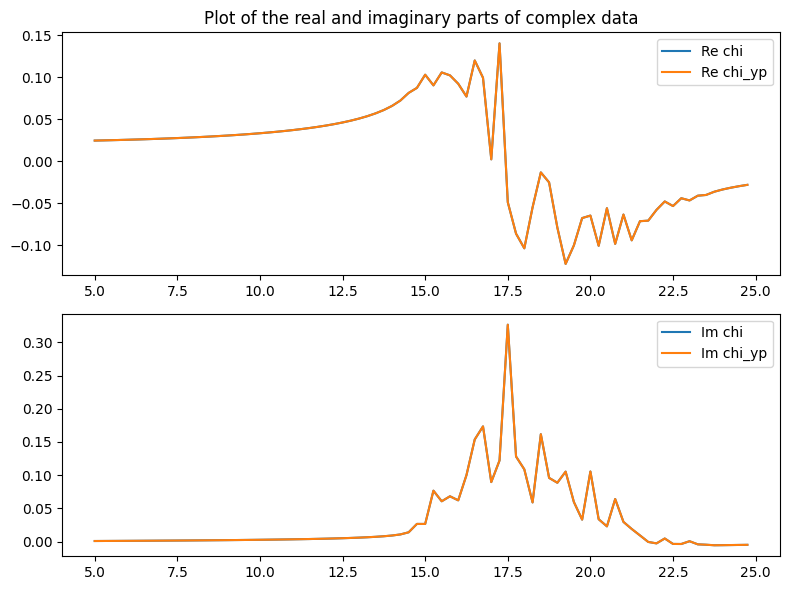

In [27]:
U.Plot_ComplexArray(freqs_freqmix,chi_freqmix[0][(1,0)],label='chi',data2=chi_freqmix_yp[17,:,0],label2='chi_yp')

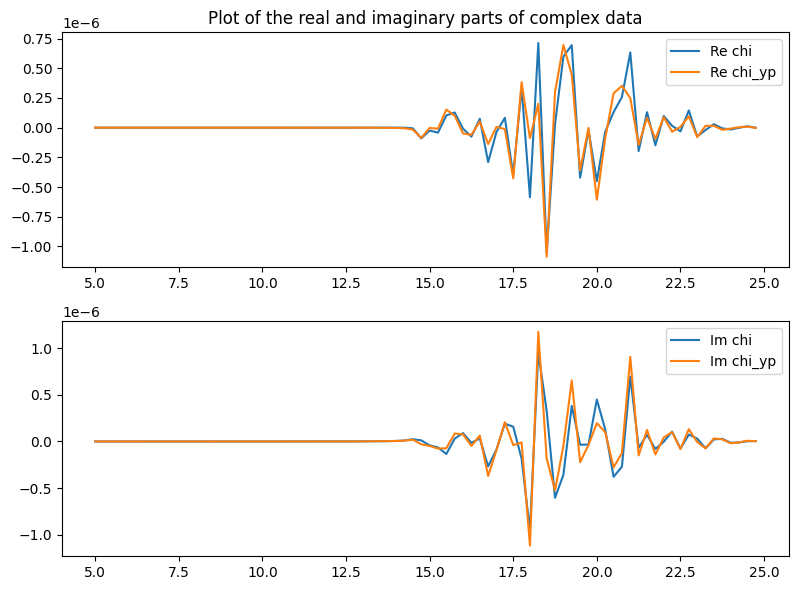

In [28]:
U.Plot_ComplexArray(freqs_freqmix,chi_freqmix[0][(1,-1)],label='chi',data2=chi_freqmix_yp[16,:,0],label2='chi_yp')

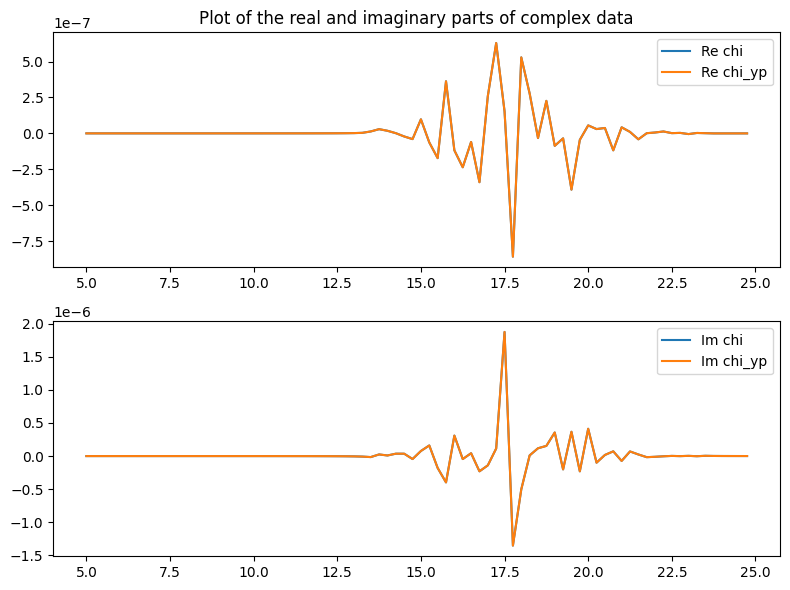

In [29]:
U.Plot_ComplexArray(freqs_freqmix,chi_freqmix[0][(1,1)],label='chi',data2=chi_freqmix_yp[18,:,0],label2='chi_yp')

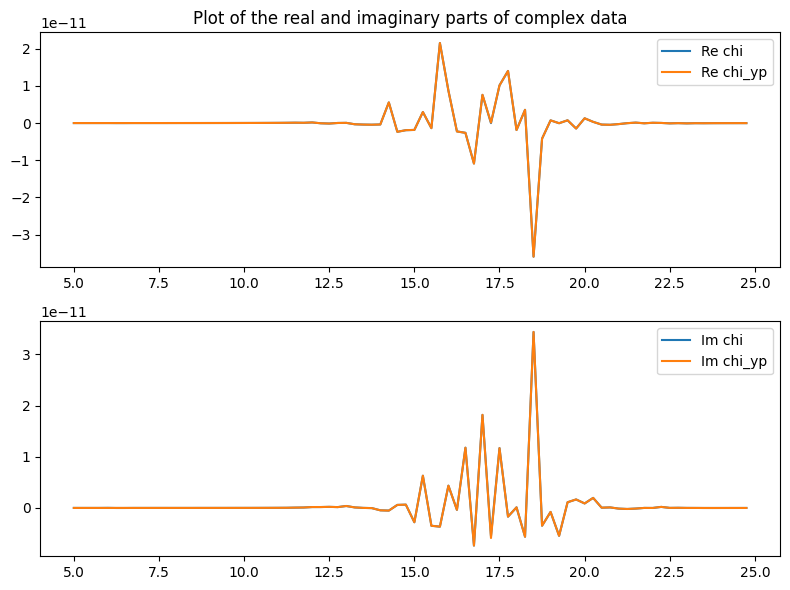

In [30]:
U.Plot_ComplexArray(freqs_freqmix,chi_freqmix[0][(1,2)],label='chi',data2=chi_freqmix_yp[19,:,0],label2='chi_yp')

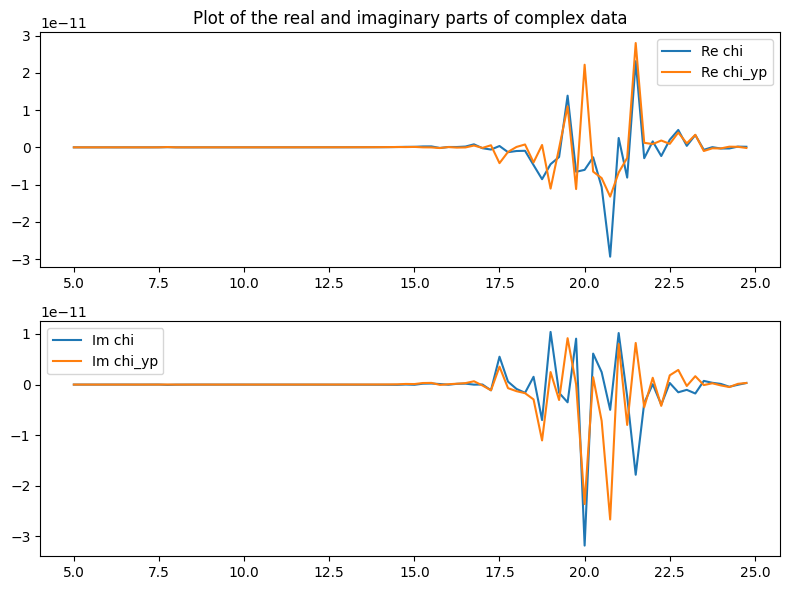

In [31]:
U.Plot_ComplexArray(freqs_freqmix,chi_freqmix[0][(1,-2)],label='chi',data2=chi_freqmix_yp[15,:,0],label2='chi_yp')